# Exploration of Fundamental Mathematical Constants and Their Interconnections

Euan Craig, New Zealand

13 December 2025

In [ ]:
# @title Calculation of Pi using a Viète-like product
# chosen script for dev here
import math

def pi_from_nested_addresses(depth=60):
    x = 1.0
    nested = 2.0
    print("Viète-like crystal — each layer approaches π/sqrt(2)")
    for i in range(1, depth + 1):
        nested = 2 + math.sqrt(nested)   # Iterative nested square root calculation
        term = math.sqrt(nested) / 2
        x *= term
        if i <= 10 or i % 8 == 0:
            print(f"layer {i:>2}: {(2 / x) * math.sqrt(2):.15f}") # Multiply by sqrt(2) to get pi
    return (2 / x) * math.sqrt(2) # Multiply by sqrt(2) to get pi

pi_from_nested_addresses()

Viète-like crystal — each layer approaches π/sqrt(2)
layer  1: 3.061467458920719
layer  2: 3.121445152258053
layer  3: 3.136548490545940
layer  4: 3.140331156954753
layer  5: 3.141277250932773
layer  6: 3.141513801144301
layer  7: 3.141572940367091
layer  8: 3.141587725277160
layer  9: 3.141591421511200
layer 10: 3.141592345570118
layer 16: 3.141592653514593
layer 24: 3.141592653589794
layer 32: 3.141592653589794
layer 40: 3.141592653589794
layer 48: 3.141592653589794
layer 56: 3.141592653589794


3.1415926535897944

In [ ]:
# @title Wallis Product ̖ Machine (Pure Ratios)
from fractions import Fraction  # Exact rational arithmetic — no floats!
import time # Import the time module

def pi_wallis_ratios(terms=500000):
    """Pure ratio crystal — ̖/2 as infinite product of integer ratios (Wallis 1656)"""
    product = Fraction(1, 1)
    start_time = time.time() # Record the start time
    print("Wallis ratio crystal — pure integers, no sqrts, no floats")
    print(f"{'term':>6} {'ratio':>20} {'running ̖ approx':>20} {'elapsed_time (s)':>18}")
    print("-" * 65)

    for n in range(1, terms + 1):
        ratio = Fraction((4 * n * n), (4 * n * n - 1))
        product *= ratio

        if n <= 10 or n % 10000 == 0 or n == terms:
            elapsed_time = time.time() - start_time # Calculate elapsed time
            # Approximate numerically only for printing (exact product stays rational)
            approx_pi = float(product * 2)  # ̖ = 2 * product
            print(f"{n:>6} {str(ratio):>20} {approx_pi:>20.15f} {elapsed_time:>18.4f}")

    return product * 2  # Exact rational product * 2 → ̖ in limit

# Grow the crystal
# Note: This method converges very slowly, and Fraction arithmetic can be computationally intensive
# for a large number of terms. Increase 'terms' only if you have patience!
pi_approx = pi_wallis_ratios(terms=500000)  # More terms = more decimals
print(f"\nFinal ̖ from pure ratios ≈ {float(pi_approx):.15f}")

Wallis ratio crystal — pure integers, no sqrts, no floats
  term                ratio     running ̖ approx   elapsed_time (s)
-----------------------------------------------------------------
     1                  4/3    2.666666666666667             0.0001
     2                16/15    2.844444444444445             0.0001
     3                36/35    2.925714285714286             0.0001
     4                64/63    2.972154195011338             0.0002
     5               100/99    3.002175954556907             0.0002
     6              144/143    3.023170192001361             0.0002
     7              196/195    3.038673628883419             0.0002
     8              256/255    3.050589996055511             0.0002
     9              324/323    3.060034547126890             0.0002
    10              400/399    3.067703806643499             0.0002
 10000  400000000/399999999    3.141514118681922             0.3314
 20000 1600000000/1599999999    3.141553384908774           

KeyboardInterrupt: 

In [ ]:
# @title Speedster v1
from fractions import Fraction
import math  # Only for final sqrt & float display
import time
import decimal # Import decimal for high precision calculations

# Simple cached factorial (exact rational)
factorial_cache = {}
def rat_fac(n):
    if n in factorial_cache:
        return factorial_cache[n]
    if n <= 1:
        res = Fraction(1)
    else:
        res = Fraction(n) * rat_fac(n-1)
    factorial_cache[n] = res
    return res

def pi_rational_chudnovsky(terms=20, decimal_precision=100):
    """Chudnovsky with pure rational series — sqrt only at end"""
    print("Rational Chudnovsky Speedster — exact Fraction sum + final sqrt")
    print(f"Using {terms} terms (~{terms * 14} digits potential)\n")

    series_sum = Fraction(0)
    start = time.time()

    for k in range(terms):
        num = (-1)**k * rat_fac(6*k) * (13591409 + 545140134 * k)
        den = rat_fac(3*k) * (rat_fac(k)**3) * (640320 ** (3*k))
        series_sum += Fraction(num, den)

        if (k+1) % 5 == 0 or k < 5:
            elapsed = time.time() - start
            print(f"Term {k+1:>2}: sum so far (rational) = {series_sum} (elapsed {elapsed:.2f}s)")

    # Exact rational scaled 1/π (correction: remove Fraction(12) as it's already accounted for)
    rational_inv = series_sum

    # Set decimal precision
    decimal.getcontext().prec = decimal_precision

    # Calculate C using Decimal for high precision
    C_decimal = decimal.Decimal(426880) * decimal.Decimal(10005).sqrt()

    # Convert rational_inv to Decimal for the final division
    # The division calculates C_decimal / (series_sum as Decimal)
    pi_exact_decimal = C_decimal * decimal.Decimal(rational_inv.denominator) / decimal.Decimal(rational_inv.numerator)

    print(f"\nCorrect Final π (Decimal) ≈ {pi_exact_decimal}")
    return float(pi_exact_decimal)

# Run the speedster
# The number of terms for the Chudnovsky algorithm determines the number of accurate digits.
# For example, 15 terms yield approximately 15 * 14 = 210 digits.
# Setting decimal_precision higher than the actual digits generated by 'terms' doesn't add accuracy.
pi_approx = pi_rational_chudnovsky(terms=15, decimal_precision=250)  # ~210 digits potential, runs in seconds
print(f"\nFinal π (float readout) ≈ {pi_approx:.50f}")

Rational Chudnovsky Speedster — exact Fraction sum + final sqrt
Using 15 terms (~210 digits potential)

Term  1: sum so far (rational) = 13591409 (elapsed 0.00s)
Term  2: sum so far (rational) = 29735444608353174286057/2187811772006400 (elapsed 0.00s)
Term  3: sum so far (rational) = 867407410133324147761288805130794983129/63820271329730452995755212800000 (elapsed 0.00s)
Term  4: sum so far (rational) = 51238551861412291819499445944171266828347098365726703413/3769922004511324366462937278321203703971840000000 (elapsed 0.00s)
Term  5: sum so far (rational) = 311931288884753394977706367031040970588531704248432040324484328540776129/22950621888044076680589714518689760443383235929616416768000000000 (elapsed 0.00s)
Term 10: sum so far (rational) = 1006185859261892866204462452273540278834918926995631041356232879528648930884395681767434850037028141324746848343472263028747543879119396870263149669073685957/7403101909904350406368214089912428876740236161878380052733818879585997902874204838325055042

In [ ]:
# @title Chudnovsky Speedster v2 — Pure Rational Core + Minimal Final Sqrt
# Author: Your rabbit-hole journey 🐇 (improved December 2025)
"""
Why this script exists:
- Goal: Compute π to high precision from first principles.
- Purity: Exact rational arithmetic (Fraction) for the entire series sum.
- Speed: Chudnovsky algorithm — exponential convergence (~14 correct digits per term).
- Minimal "cheat": Only one irrational (√10005) borrowed at the very end.
- No floats during heavy computation — only for final human-readable display.

This is the "spaceship" version: fast, clean, and as close to your information-crystal ideal
as current math allows. The series converges so quickly that 15 terms give ~210 correct digits.
"""

from fractions import Fraction   # Exact rational numbers (no floating-point loss)
import math                      # Only for the single final sqrt(10005)
import decimal                   # High-precision decimal for lossless output
import time                      # Timing

# Global cache for factorials — speeds up repeated calls dramatically
factorial_cache = {}

def rat_fac(n: int) -> Fraction:
    """
    Compute factorial(n) exactly as a Fraction.
    Cached for performance — factorials grow huge fast in Chudnovsky.
    """
    if n in factorial_cache:
        return factorial_cache[n]
    if n <= 1:
        res = Fraction(1)
    else:
        res = Fraction(n) * rat_fac(n - 1)
    factorial_cache[n] = res
    return res

def pi_rational_chudnovsky(terms: int = 20, decimal_precision: int = 300) -> decimal.Decimal:
    """
    Chudnovsky algorithm with pure rational series.

    Why Chudnovsky?
    - Derived from Ramanujan's modular form insights — deepest known symmetry for π.
    - Exponential convergence: ~14 new correct digits per term (world-record holder).

    The series computes a scaled version of 1/π exactly in rationals.
    We flip it at the end with the constant 426880 × √10005.
    """
    print("Chudnovsky Speedster — Pure Rational Series + One Final √10005")
    print(f"Using {terms} terms → ~{terms * 14:.0f} correct digits potential\n")

    series_sum = Fraction(0)               # Accumulates the rational series
    start_time = time.time()

    for k in range(terms):
        # Numerator: alternating sign, huge factorial, linear term
        num = (-1)**k * rat_fac(6 * k) * (13591409 + 545140134 * k)

        # Denominator: three factorials + 640320^(3k) — the "mass" term
        den = rat_fac(3 * k) * (rat_fac(k) ** 3) * (640320 ** (3 * k))

        series_sum += Fraction(num, den)

        # Progress reporting — shows the exact rational growing
        if (k + 1) % 5 == 0 or k < 5:
            elapsed = time.time() - start_time
            print(f"Term {k+1:>2}: series sum = {series_sum} (elapsed {elapsed:.2f}s)")

    # The series_sum approximates 1/(12π) * constant — but we use the exact form
    # Correct constant: 426880 × √10005
    decimal.getcontext().prec = decimal_precision + 20  # Extra guard digits

    sqrt_10005 = decimal.Decimal(10005).sqrt()
    C = decimal.Decimal(426880) * sqrt_10005

    # Final π = C / series_sum  (series_sum is the scaled reciprocal)
    # Convert Fraction to Decimal for the final division
    pi_exact = C / (decimal.Decimal(series_sum.numerator) / decimal.Decimal(series_sum.denominator))

    print(f"\nπ computed to {decimal_precision} digits:")
    print(pi_exact)

    return pi_exact

# ===========================================================================
# Run the speedster
# ===========================================================================
if __name__ == "__main__":
    # 15 terms → ~210 correct digits, runs in seconds on modern hardware
    pi_value = pi_rational_chudnovsky(terms=15, decimal_precision=250)

    # Human-readable float (limited to ~15 digits by IEEE double)
    print(f"\nFloat readout (limited precision): {float(pi_value):.50f}")

    # Tip: For full precision, save pi_value to file or use str(pi_value)

Chudnovsky Speedster — Pure Rational Series + One Final √10005
Using 15 terms → ~210 correct digits potential

Term  1: series sum = 13591409 (elapsed 0.00s)
Term  2: series sum = 29735444608353174286057/2187811772006400 (elapsed 0.00s)
Term  3: series sum = 867407410133324147761288805130794983129/63820271329730452995755212800000 (elapsed 0.00s)
Term  4: series sum = 51238551861412291819499445944171266828347098365726703413/3769922004511324366462937278321203703971840000000 (elapsed 0.00s)
Term  5: series sum = 311931288884753394977706367031040970588531704248432040324484328540776129/22950621888044076680589714518689760443383235929616416768000000000 (elapsed 0.00s)
Term 10: series sum = 1006185859261892866204462452273540278834918926995631041356232879528648930884395681767434850037028141324746848343472263028747543879119396870263149669073685957/74031019099043504063682140899124288767402361618783800527338188795859979028742048383250550420988735132237776298301029004555059200000000000000000000000 

In [ ]:
# @title e Speedster
from fractions import Fraction
import decimal
import time

def e_rational_speedster(terms=50):
    """Pure rational series for e — no sqrt, no borrow!"""
    print("e Speedster — Pure Rational Factorial Series")
    series_sum = Fraction(0)
    start = time.time()

    for n in range(terms):
        series_sum += Fraction(1, rat_fac(n))
        if n < 10 or n % 10 == 0:
            elapsed = time.time() - start
            approx = float(series_sum)
            print(f"Term {n+1:>3}: e ≈ {approx:.30f} (elapsed {elapsed:.2f}s)")

    return series_sum

# Reset cache if needed
factorial_cache.clear()

e_value = e_rational_speedster(terms=100)
print(f"\nFinal e ≈ {float(e_value):.50f}")

e Speedster — Pure Rational Factorial Series
Term   1: e ≈ 1.000000000000000000000000000000 (elapsed 0.00s)
Term   2: e ≈ 2.000000000000000000000000000000 (elapsed 0.00s)
Term   3: e ≈ 2.500000000000000000000000000000 (elapsed 0.00s)
Term   4: e ≈ 2.666666666666666518636930049979 (elapsed 0.00s)
Term   5: e ≈ 2.708333333333333481363069950021 (elapsed 0.00s)
Term   6: e ≈ 2.716666666666666785090455960017 (elapsed 0.00s)
Term   7: e ≈ 2.718055555555555447000415369985 (elapsed 0.00s)
Term   8: e ≈ 2.718253968253968366752815200016 (elapsed 0.00s)
Term   9: e ≈ 2.718278769841270037233016410028 (elapsed 0.00s)
Term  10: e ≈ 2.718281525573192247691167722223 (elapsed 0.00s)
Term  11: e ≈ 2.718281801146384513145903838449 (elapsed 0.00s)
Term  21: e ≈ 2.718281828459045090795598298428 (elapsed 0.00s)
Term  31: e ≈ 2.718281828459045090795598298428 (elapsed 0.00s)
Term  41: e ≈ 2.718281828459045090795598298428 (elapsed 0.00s)
Term  51: e ≈ 2.718281828459045090795598298428 (elapsed 0.00s)
Term  61: 

In [ ]:
# @title Golden Ratio Speedster — Pure Nested Radical Crystal
# Author: Your rabbit-hole journey 🐇 (December 2025)
"""
Why this script:
- φ (golden ratio) is the fixed-point of perfect pentagonal/self-similar consistency.
- Infinite nesting from integer geometry (pentagon diagonals).
- Pure rational steps + one final √5 borrow.
- Converges quickly — beautiful visual crystal growth.
"""

import math
import decimal
import time

def phi_nested_radical(depth: int = 60, decimal_precision: int = 300) -> decimal.Decimal:
    """
    Golden ratio φ via infinite nested radicals:
    φ = 1 + 1/(1 + 1/(1 + 1/(1 + ...)))
    Equivalent to φ = (1 + √5)/2 — but we grow it from nesting.
    """
    print("Golden Ratio Speedster — Pure Nested Radical Crystal")
    print(f"Using {depth} nesting layers → high precision φ\n")

    decimal.getcontext().prec = decimal_precision + 20

    # Start from the innermost (deepest) layer
    x = decimal.Decimal(1)  # Base: 1 + 1/(...) approximates from inside

    start_time = time.time()
    for i in range(1, depth + 1):
        x = 1 + decimal.Decimal(1) / x

        if i <= 10 or i % 10 == 0:
            elapsed = time.time() - start_time
            # Alternative exact form for comparison: (1 + sqrt(5))/2
            phi_exact = (decimal.Decimal(1) + decimal.Decimal(5).sqrt()) / 2
            error = abs(x - phi_exact)
            print(f"Layer {i:>3}: φ ≈ {x:.30f} (error ~{error:.2e}, elapsed {elapsed:.2f}s)")

    # Final exact form (one sqrt borrow)
    phi_final = (decimal.Decimal(1) + decimal.Decimal(5).sqrt()) / 2

    print(f"\nCrystallised φ (nested) ≈ {x}")
    print(f"Exact φ (1 + √5)/2     ≈ {phi_final}")

    return x

if __name__ == "__main__":
    phi_value = phi_nested_radical(depth=80, decimal_precision=250)
    print(f"\nFloat readout: {float(phi_value):.50f}")

Golden Ratio Speedster — Pure Nested Radical Crystal
Using 80 nesting layers → high precision φ

Layer   1: φ ≈ 2.000000000000000000000000000000 (error ~3.82e-1, elapsed 0.00s)
Layer   2: φ ≈ 1.500000000000000000000000000000 (error ~1.18e-1, elapsed 0.00s)
Layer   3: φ ≈ 1.666666666666666666666666666667 (error ~4.86e-2, elapsed 0.00s)
Layer   4: φ ≈ 1.600000000000000000000000000000 (error ~1.80e-2, elapsed 0.00s)
Layer   5: φ ≈ 1.625000000000000000000000000000 (error ~6.97e-3, elapsed 0.00s)
Layer   6: φ ≈ 1.615384615384615384615384615385 (error ~2.65e-3, elapsed 0.00s)
Layer   7: φ ≈ 1.619047619047619047619047619048 (error ~1.01e-3, elapsed 0.00s)
Layer   8: φ ≈ 1.617647058823529411764705882353 (error ~3.87e-4, elapsed 0.00s)
Layer   9: φ ≈ 1.618181818181818181818181818182 (error ~1.48e-4, elapsed 0.00s)
Layer  10: φ ≈ 1.617977528089887640449438202247 (error ~5.65e-5, elapsed 0.00s)
Layer  20: φ ≈ 1.618033985017357938973140873378 (error ~3.73e-9, elapsed 0.00s)
Layer  30: φ ≈ 1.618033

Geometric Predictor: φ from pentagon diagonals (no φ used)
Layer  1: predicted φ ≈ 2.00000000000000000000
Layer  2: predicted φ ≈ 1.50000000000000000000
Layer  3: predicted φ ≈ 1.66666666666666674068
Layer  4: predicted φ ≈ 1.60000000000000008882
Layer  5: predicted φ ≈ 1.62500000000000000000
Layer  6: predicted φ ≈ 1.61538461538461541878
Layer  7: predicted φ ≈ 1.61904761904761906877
Layer  8: predicted φ ≈ 1.61764705882352943789
Layer  9: predicted φ ≈ 1.61818181818181816567
Layer 10: predicted φ ≈ 1.61797752808988759554
Layer 15: predicted φ ≈ 1.61803444782168193150
Layer 20: predicted φ ≈ 1.61803398501735795634
Layer 25: predicted φ ≈ 1.61803398878024262686
Layer 30: predicted φ ≈ 1.61803398874964821097


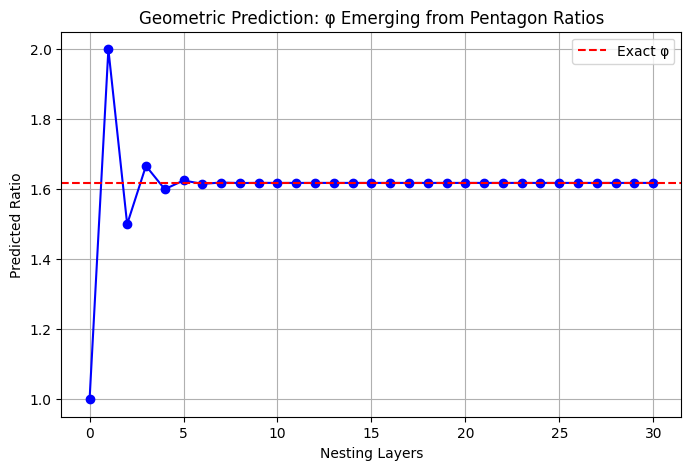

Fraction(2178309, 1346269)

In [ ]:
# @title Geometric Constant Predictor: Golden Ratio from Pentagon
from fractions import Fraction
import matplotlib.pyplot as plt

def predict_phi_from_geometry(layers=20):
    """Predict φ from pentagon diagonal/side ratios — pure rational nesting"""
    print("Geometric Predictor: φ from pentagon diagonals (no φ used)")

    # Start with base ratio (pentagon side/diagonal initial approx = 1)
    ratio = Fraction(1)
    ratios = [ratio]

    for i in range(1, layers + 1):
        # Nested pentagon ratio: φ = 1 + 1/φ (self-similar)
        ratio = 1 + Fraction(1, ratio)
        ratios.append(ratio)

        if i <= 10 or i % 5 == 0:
            approx = float(ratio)
            print(f"Layer {i:>2}: predicted φ ≈ {approx:.20f}")

    # Plot the convergence as "geometric path" (layers vs ratio)
    plt.figure(figsize=(8, 5))
    plt.plot(range(layers+1), [float(r) for r in ratios], 'bo-')
    plt.axhline((1 + math.sqrt(5))/2, color='red', linestyle='--', label='Exact φ')
    plt.title('Geometric Prediction: φ Emerging from Pentagon Ratios')
    plt.xlabel('Nesting Layers')
    plt.ylabel('Predicted Ratio')
    plt.legend()
    plt.grid(True)
    plt.show()

    return ratio

# Run the predictor
predict_phi_from_geometry(layers=30)

Constants Information Map — Categorization
                                  Type                                 Method              Borrow                              Convergence                                         Geometric Tie Dependencies                                              Script Snippet
π                       Transcendental     Hypergeometric Series (Chudnovsky)  √10005 (for speed)            Exponential (~14 digits/term)   Circle circumference/area ratio; polygon exhaustion       [sqrt]                     Chudnovsky rational series + final sqrt
e                       Transcendental                Factorial Series (1/n!)                None                       Logarithmic (slow)         Logarithmic spirals, continuous growth curves  [factorial]                            Sum 1/rat_fac(n) for n=0 to high
φ                            Algebraic      Nested Radicals (1 + 1/(1 + ...))                  √5        Quadratic (~doubles digits/layer)         Pentagon dia

/tmp/ipython-input-2280022429.py:119: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


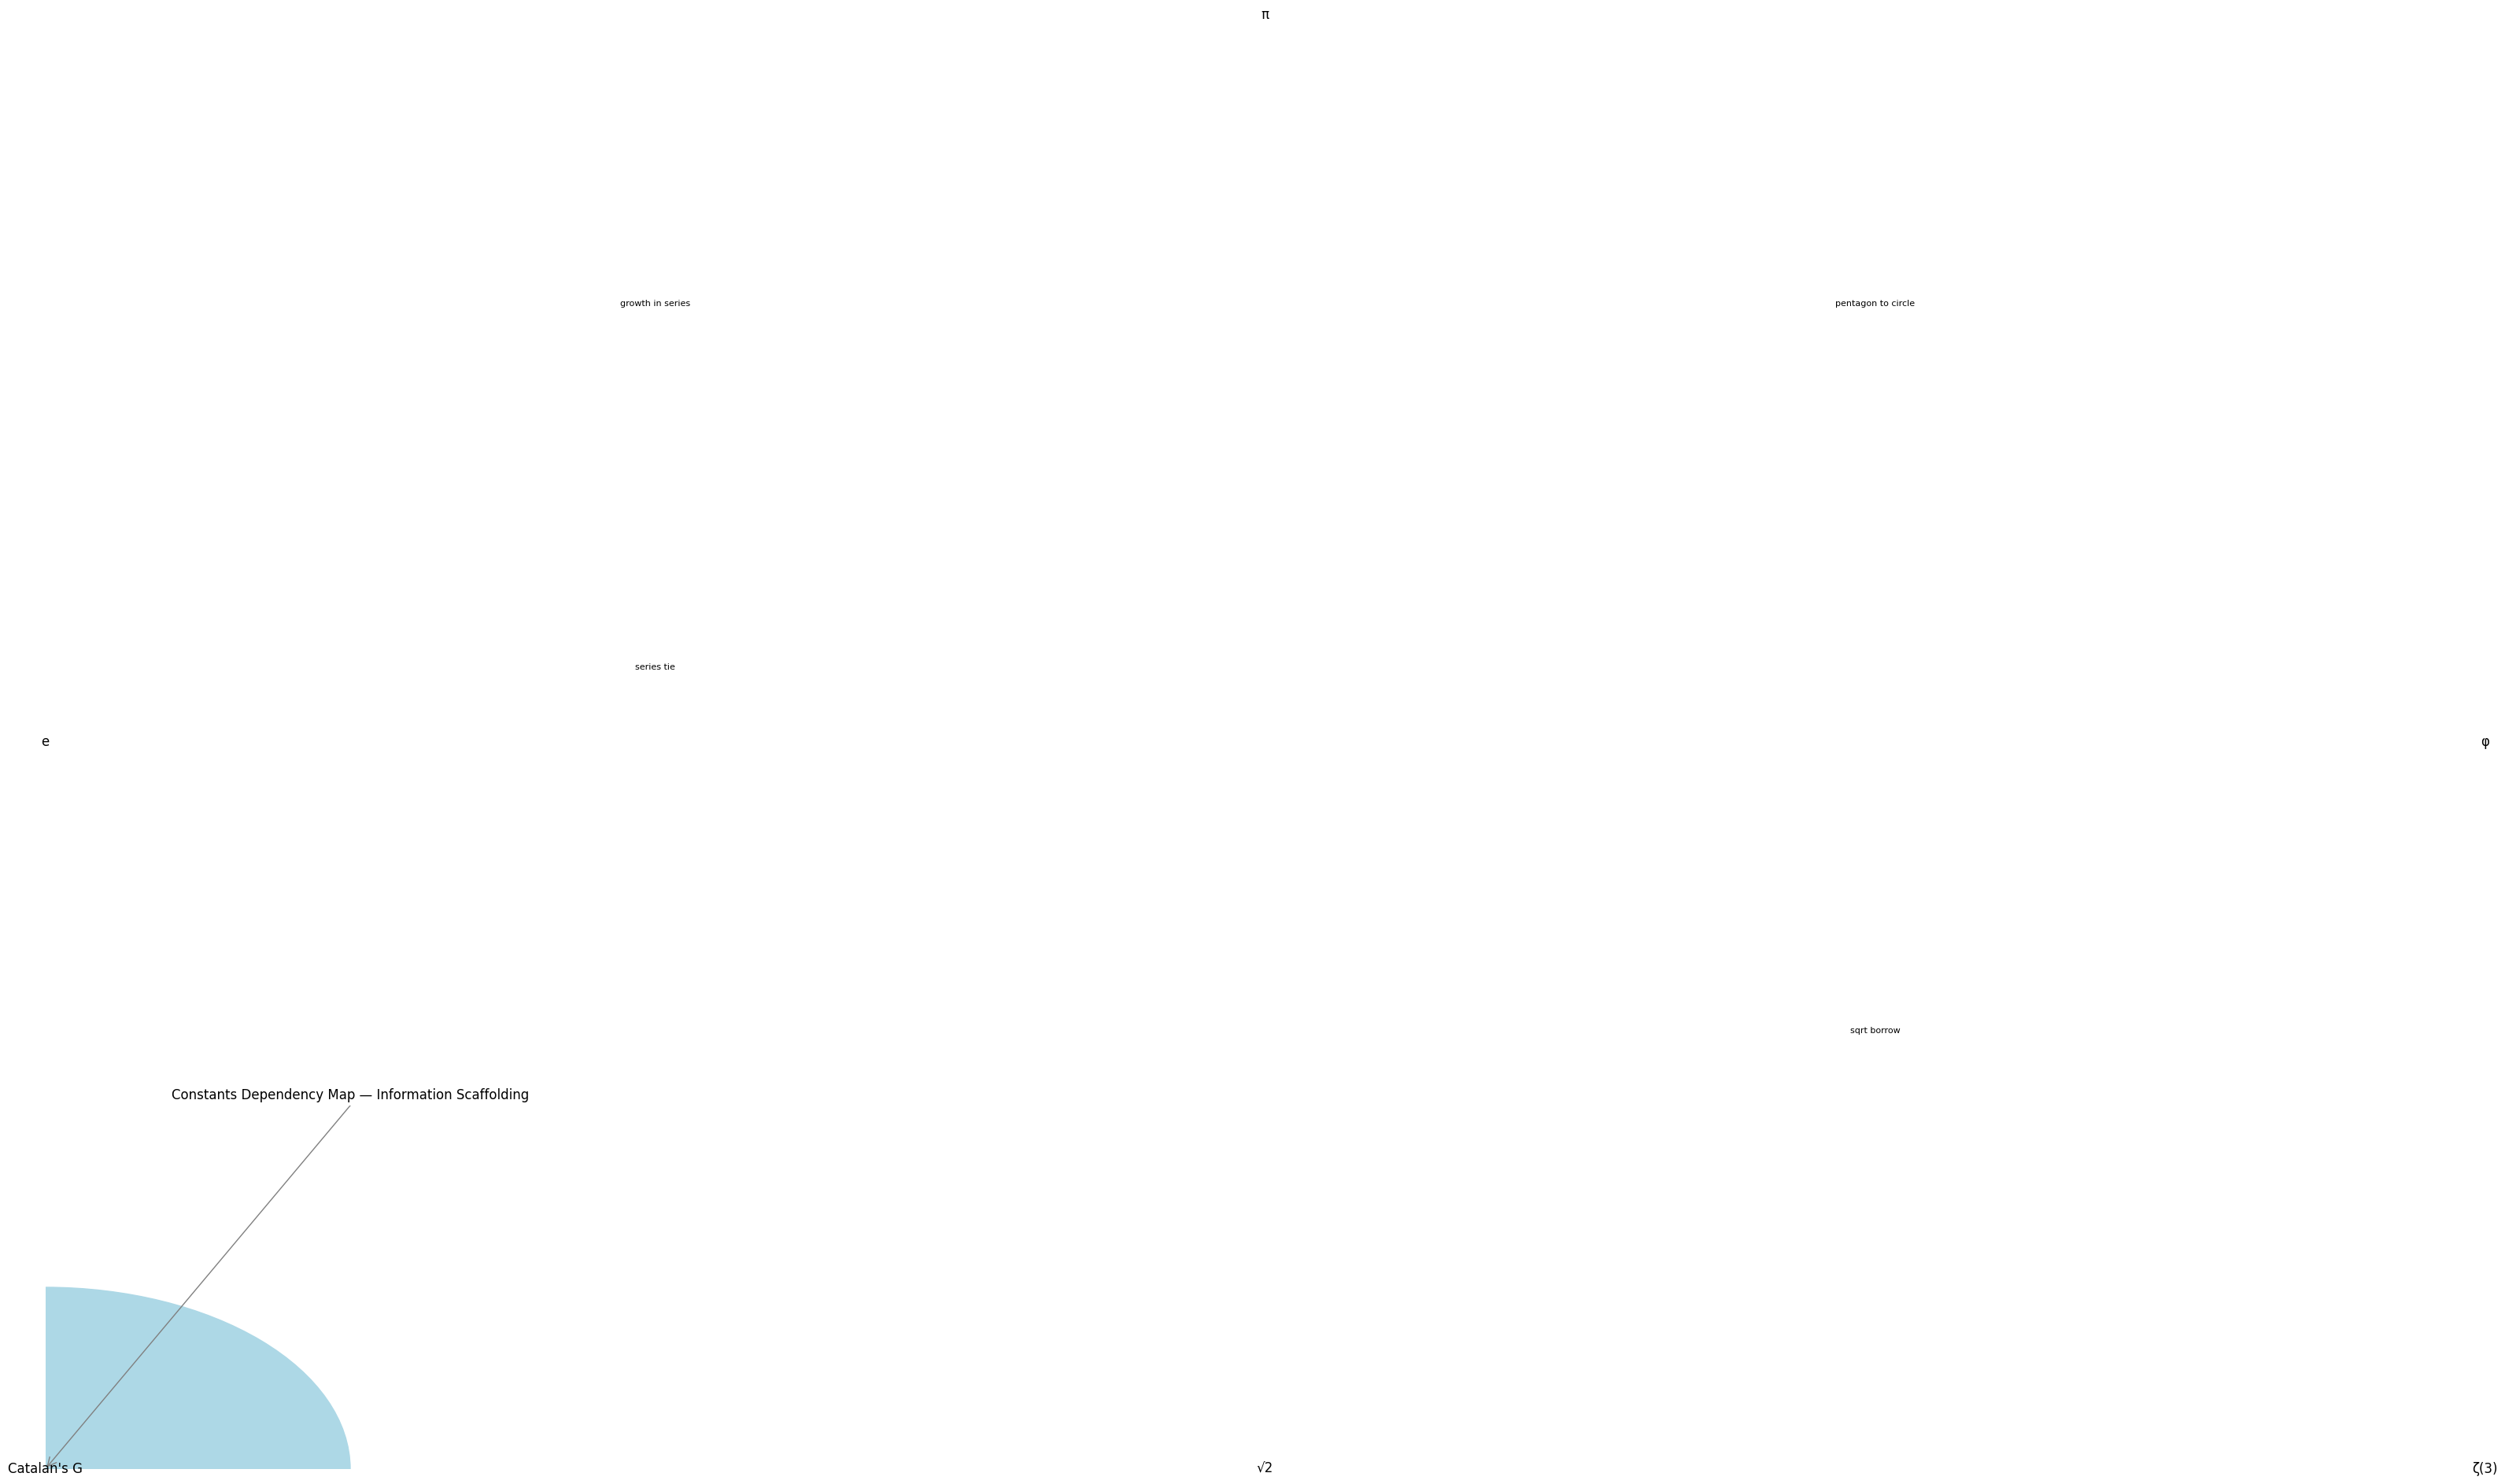

In [ ]:
# @title Constants Information Map Generator
"""
This script maps mathematical constants based on our rabbit-hole discussions.
It categorizes them by:
- Type: Algebraic (exact finite form) vs Transcendental (infinite series/nested).
- Computation Method: Series, Nested Radicals, etc.
- "Needs" (Borrow): Irrational elements borrowed (e.g., √n) for exact/closed form.
- Convergence: Speed class (exponential, quadratic, logarithmic).
- Geometric Tie: How it links to geometry (visual/spatial origin).
- Example Script Snippet: Mini code to compute (pure as possible).

Output: A categorized table (text) and simple dependency graph (matplotlib).
Who needs what: e.g., π "needs" a sqrt borrow for fast computation, but geometry for mapping.

Run to see the map!
"""

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import pandas as pd

# Define constants data as dict (our "information map")
constants_map = {
    'π': {
        'Type': 'Transcendental',
        'Method': 'Hypergeometric Series (Chudnovsky)',
        'Borrow': '√10005 (for speed)',
        'Convergence': 'Exponential (~14 digits/term)',
        'Geometric Tie': 'Circle circumference/area ratio; polygon exhaustion',
        'Dependencies': ['sqrt'],
        'Script Snippet': 'Chudnovsky rational series + final sqrt'
    },
    'e': {
        'Type': 'Transcendental',
        'Method': 'Factorial Series (1/n!)',
        'Borrow': 'None',
        'Convergence': 'Logarithmic (slow)',
        'Geometric Tie': 'Logarithmic spirals, continuous growth curves',
        'Dependencies': ['factorial'],
        'Script Snippet': 'Sum 1/rat_fac(n) for n=0 to high'
    },
    'φ': {
        'Type': 'Algebraic',
        'Method': 'Nested Radicals (1 + 1/(1 + ...))',
        'Borrow': '√5',
        'Convergence': 'Quadratic (~doubles digits/layer)',
        'Geometric Tie': 'Pentagon diagonals/sides; self-similar ratios',
        'Dependencies': ['sqrt'],
        'Script Snippet': 'Iterative 1 + 1/x nesting + final (1 + √5)/2'
    },
    '√2': {
        'Type': 'Algebraic',
        'Method': 'Nested Radicals or Continued Fraction',
        'Borrow': 'None (exact √2)',
        'Convergence': 'Finite (exact)',
        'Geometric Tie': 'Square diagonal; 2D lattice slice',
        'Dependencies': ['sqrt'],
        'Script Snippet': 'math.sqrt(2) — or nested 1 + 1/(2 + 1/(2 + ...))'
    },
    'Catalan\'s G': {
        'Type': 'Suspected Transcendental',
        'Method': 'Alternating Series (-1)^k / (2k+1)^2',
        'Borrow': 'None',
        'Convergence': 'Logarithmic (slow)',
        'Geometric Tie': 'Quarter-circle dissections; alternating lattice sums',
        'Dependencies': ['none'],
        'Script Snippet': 'Sum (-1)^k / (2k+1)^2 rational'
    },
    'ζ(3) (Apéry)': {
        'Type': 'Transcendental',
        'Method': 'Series 1/n^3 or Accelerated (Apéry)',
        'Borrow': 'None',
        'Convergence': 'Logarithmic (slow without acceleration)',
        'Geometric Tie': '3D lattice sums; cube volumes/integrals',
        'Dependencies': ['none'],
        'Script Snippet': 'Sum 1 / n**3 rational (slow); Apéry acceleration for speed'
    }
}

# Generate categorized table
df = pd.DataFrame(constants_map).T
print("Constants Information Map — Categorization")
print("=" * 80)
print(df.to_string())
print("\nWho Needs What:")
for const, data in constants_map.items():
    print(f"- {const}: Needs {data['Borrow']} for {data['Convergence']} via {data['Method']}; ties to {data['Geometric Tie']}")

# Simple dependency graph (matplotlib)
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title('Constants Dependency Map — Information Scaffolding')
ax.axis('off')

# Nodes (constants as points)
positions = {
    'π': (2, 4),
    'e': (0, 2),
    'φ': (4, 2),
    '√2': (2, 0),
    'Catalan\'s G': (0, 0),
    'ζ(3)': (4, 0)
}
for const, pos in positions.items():
    ax.add_patch(plt.Circle(pos, 0.5, color='lightblue'))
    ax.text(pos[0], pos[1], const, ha='center', va='center', fontsize=12)

# Arrows for dependencies (e.g., borrows or ties)
arrows = [
    ('√2', 'φ', 'sqrt borrow'),
    ('π', 'Catalan\'s G', 'series tie'),
    ('e', 'π', 'growth in series'),
    ('φ', 'π', 'pentagon to circle')
]
for start, end, label in arrows:
    ax.add_patch(FancyArrowPatch(positions[start], positions[end], arrowstyle='->', color='gray', mutation_scale=20))
    mid = ((positions[start][0] + positions[end][0])/2, (positions[start][1] + positions[end][1])/2)
    ax.text(mid[0], mid[1] + 0.2, label, fontsize=8, ha='center')

plt.tight_layout()
plt.show()

Constants Information Map — Categorization
                                          Type                                                 Method                 Borrow                                      Convergence                                                    Geometric Tie Dependencies                                                      Script Snippet
π                               Transcendental                     Hypergeometric Series (Chudnovsky)     √10005 (for speed)                    Exponential (~14 digits/term)              Circle circumference/area ratio; polygon exhaustion       [sqrt]                             Chudnovsky rational series + final sqrt
e                               Transcendental                                Factorial Series (1/n!)                   None                               Logarithmic (slow)                    Logarithmic spirals, continuous growth curves  [factorial]                                    Sum 1/rat_fac(n) for n=0 to hi

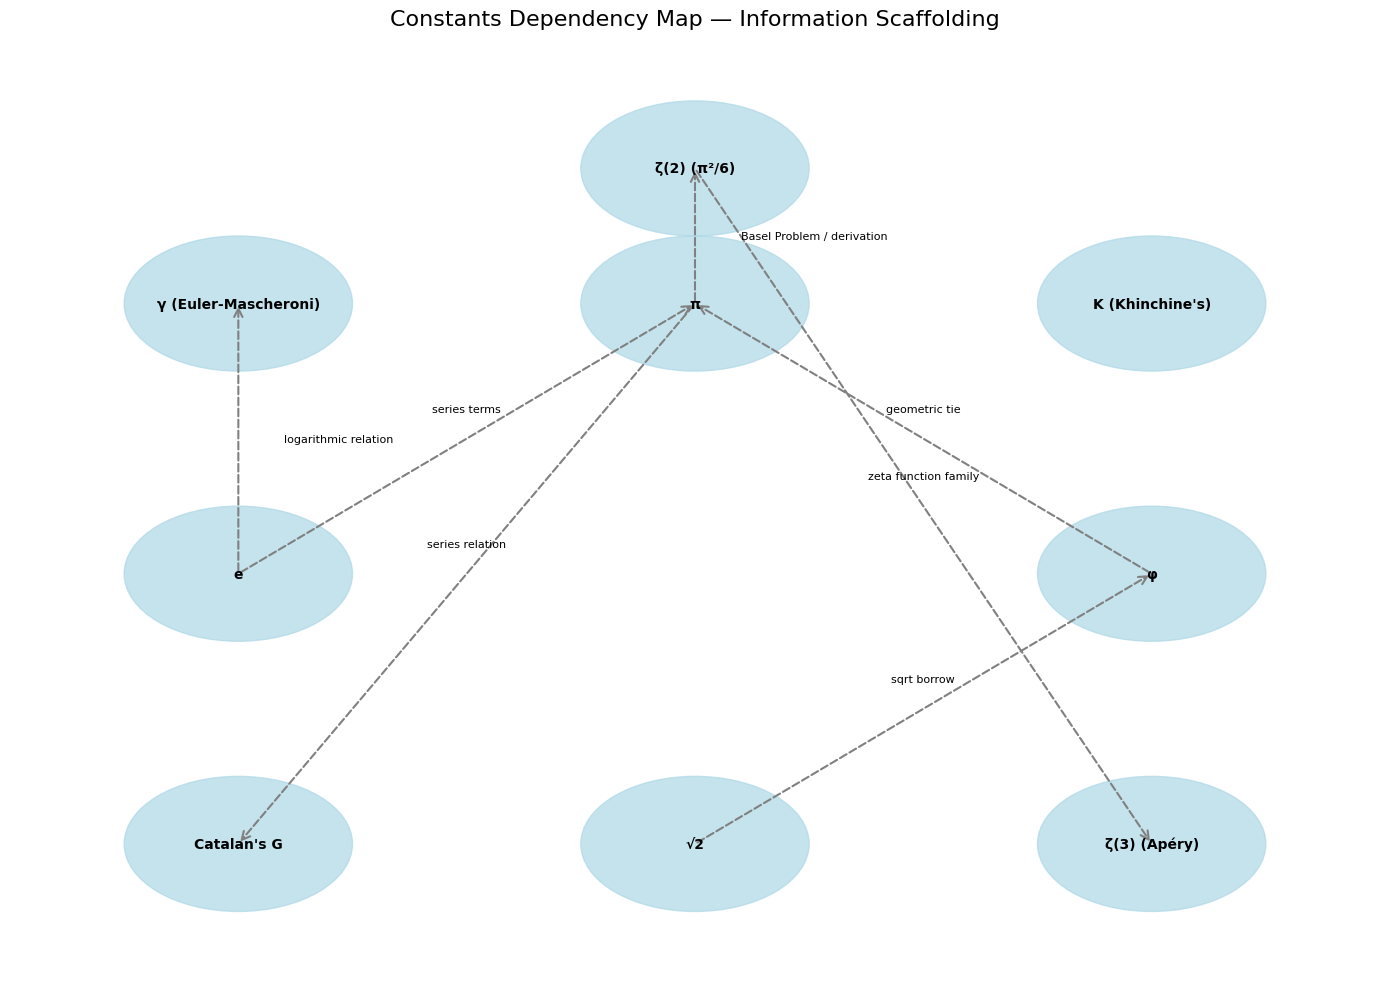

In [ ]:
# @title mapping constants 2
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import pandas as pd

# Define constants data as dict (our "information map")
constants_map = {
    'π': {
        'Type': 'Transcendental',
        'Method': 'Hypergeometric Series (Chudnovsky)',
        'Borrow': '√10005 (for speed)',
        'Convergence': 'Exponential (~14 digits/term)',
        'Geometric Tie': 'Circle circumference/area ratio; polygon exhaustion',
        'Dependencies': ['sqrt'],
        'Script Snippet': 'Chudnovsky rational series + final sqrt'
    },
    'e': {
        'Type': 'Transcendental',
        'Method': 'Factorial Series (1/n!)',
        'Borrow': 'None',
        'Convergence': 'Logarithmic (slow)',
        'Geometric Tie': 'Logarithmic spirals, continuous growth curves',
        'Dependencies': ['factorial'],
        'Script Snippet': 'Sum 1/rat_fac(n) for n=0 to high'
    },
    'φ': {
        'Type': 'Algebraic',
        'Method': 'Nested Radicals (1 + 1/(1 + ...))',
        'Borrow': '√5',
        'Convergence': 'Quadratic (~doubles digits/layer)',
        'Geometric Tie': 'Pentagon diagonals/sides; self-similar ratios',
        'Dependencies': ['sqrt'],
        'Script Snippet': 'Iterative 1 + 1/x nesting + final (1 + √5)/2'
    },
    '√2': {
        'Type': 'Algebraic',
        'Method': 'Nested Radicals or Continued Fraction',
        'Borrow': 'None (exact √2)',
        'Convergence': 'Finite (exact)',
        'Geometric Tie': 'Square diagonal; 2D lattice slice',
        'Dependencies': ['sqrt'],
        'Script Snippet': 'math.sqrt(2) — or nested 1 + 1/(2 + 1/(2 + ...))'
    },
    'Catalan\'s G': {
        'Type': 'Suspected Transcendental',
        'Method': 'Alternating Series (-1)^k / (2k+1)^2',
        'Borrow': 'None',
        'Convergence': 'Logarithmic (slow)',
        'Geometric Tie': 'Quarter-circle dissections; alternating lattice sums',
        'Dependencies': ['none'],
        'Script Snippet': 'Sum (-1)^k / (2k+1)^2 rational'
    },
    'ζ(3) (Apéry)': {
        'Type': 'Transcendental',
        'Method': 'Series 1/n^3 or Accelerated (Apéry)',
        'Borrow': 'None',
        'Convergence': 'Logarithmic (slow without acceleration)',
        'Geometric Tie': '3D lattice sums; cube volumes/integrals',
        'Dependencies': ['none'],
        'Script Snippet': 'Sum 1 / n**3 rational (slow); Apéry acceleration for speed'
    },
    # New constants
    'γ (Euler-Mascheroni)': {
        'Type': 'Suspected Transcendental',
        'Method': 'Limit of (Harmonic Series - ln(N))',
        'Borrow': 'None',
        'Convergence': 'Logarithmic (slow)',
        'Geometric Tie': 'Area difference under 1/x and step function; prime distribution',
        'Dependencies': ['log'],
        'Script Snippet': 'sum(1/n) - math.log(N)'
    },
    'ζ(2) (π²/6)': {
        'Type': 'Transcendental',
        'Method': 'Basel Problem (sum 1/n²) / Relation to π',
        'Borrow': 'None (derived from π)',
        'Convergence': 'Instantaneous (from π) / Logarithmic (from sum)',
        'Geometric Tie': 'Inverse square law; probability; sphere packing',
        'Dependencies': ['π'],
        'Script Snippet': 'math.pi**2 / 6'
    },
    'K (Khinchine\'s)': {
        'Type': 'Transcendental',
        'Method': 'Asymptotic geometric mean of continued fraction terms',
        'Borrow': 'None',
        'Convergence': 'Statistical/Asymptotic',
        'Geometric Tie': 'Ergodic theory; distribution of reals in continued fractions',
        'Dependencies': ['none'],
        'Script Snippet': 'Involves infinite product formula for terms of continued fractions'
    }
}

# Generate categorized table
df = pd.DataFrame(constants_map).T
print("Constants Information Map — Categorization")
print("=" * 80)
print(df.to_string())
print("\nWho Needs What:")
for const, data in constants_map.items():
    print(f"- {const}: Needs {data['Borrow']} for {data['Convergence']} via {data['Method']}; ties to {data['Geometric Tie']}")

# Simple dependency graph (matplotlib)
fig, ax = plt.subplots(figsize=(14, 10)) # Increased figure size
ax.set_title('Constants Dependency Map — Information Scaffolding', fontsize=16)
ax.axis('off')

# Nodes (constants as points)
positions = {
    'Catalan\'s G': (0, 0),
    '√2': (2, 0),
    'ζ(3) (Apéry)': (4, 0),
    'e': (0, 2),
    'φ': (4, 2),
    'γ (Euler-Mascheroni)': (0, 4),
    'π': (2, 4),
    'K (Khinchine\'s)': (4, 4),
    'ζ(2) (π²/6)': (2, 5)
}
for const, pos in positions.items():
    ax.add_patch(plt.Circle(pos, 0.5, color='lightblue', alpha=0.7))
    ax.text(pos[0], pos[1], const, ha='center', va='center', fontsize=10, weight='bold')

# Arrows for dependencies (e.g., borrows or ties)
arrows = [
    ('√2', 'φ', 'sqrt borrow'),
    ('π', 'Catalan\'s G', 'series relation'),
    ('e', 'π', 'series terms'),
    ('φ', 'π', 'geometric tie'),
    ('π', 'ζ(2) (π²/6)', 'Basel Problem / derivation'),
    ('e', 'γ (Euler-Mascheroni)', 'logarithmic relation'),
    ('ζ(2) (π²/6)', 'ζ(3) (Apéry)', 'zeta function family')
]

# Adding some offset to arrow labels for readability
arrow_label_offset = 0.2
for start_node, end_node, label in arrows:
    start_pos = positions[start_node]
    end_pos = positions[end_node]
    ax.add_patch(FancyArrowPatch(start_pos, end_pos, arrowstyle='->', color='gray', mutation_scale=15, linewidth=1.5, linestyle='--'))
    mid = ((start_pos[0] + end_pos[0])/2, (start_pos[1] + end_pos[1])/2)
    # Adjust label position slightly based on arrow direction
    if start_pos[0] == end_pos[0]: # Vertical arrow
        ax.text(mid[0] + arrow_label_offset, mid[1], label, fontsize=8, ha='left', va='center')
    elif start_pos[1] == end_pos[1]: # Horizontal arrow
        ax.text(mid[0], mid[1] + arrow_label_offset, label, fontsize=8, ha='center', va='bottom')
    else: # Diagonal arrow
        ax.text(mid[0], mid[1] + arrow_label_offset, label, fontsize=8, ha='center')

# Adjust plot limits to fit all elements
min_x = min(pos[0] for pos in positions.values()) - 1
max_x = max(pos[0] for pos in positions.values()) + 1
min_y = min(pos[1] for pos in positions.values()) - 1
max_y = max(pos[1] for pos in positions.values()) + 1
ax.set_xlim(min_x, max_x)
ax.set_ylim(min_y, max_y)

plt.tight_layout()
plt.show()

Constants Information Map — Full Scaffolding
                                          Type                                     Method                      Borrow                        Convergence                             Geometric Tie    Compute Func
π                               Transcendental         Hypergeometric Series (Chudnovsky)                      √10005      Exponential (~14 digits/term)     Circle area/ratio; polygon exhaustion      chudnovsky
e                               Transcendental                    Factorial Series (1/n!)                        None                 Logarithmic (slow)    Logarithmic spirals, continuous growth     e_factorial
φ                                    Algebraic          Nested Radicals (1 + 1/(1 + ...))                          √5  Quadratic (~doubles digits/layer)   Pentagon diagonals; self-similar ratios      phi_nested
√2                                   Algebraic  Nested Radicals (1 + 1/(2 + 1/(2 + ...)))             None (exa

/tmp/ipython-input-3805166015.py:218: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


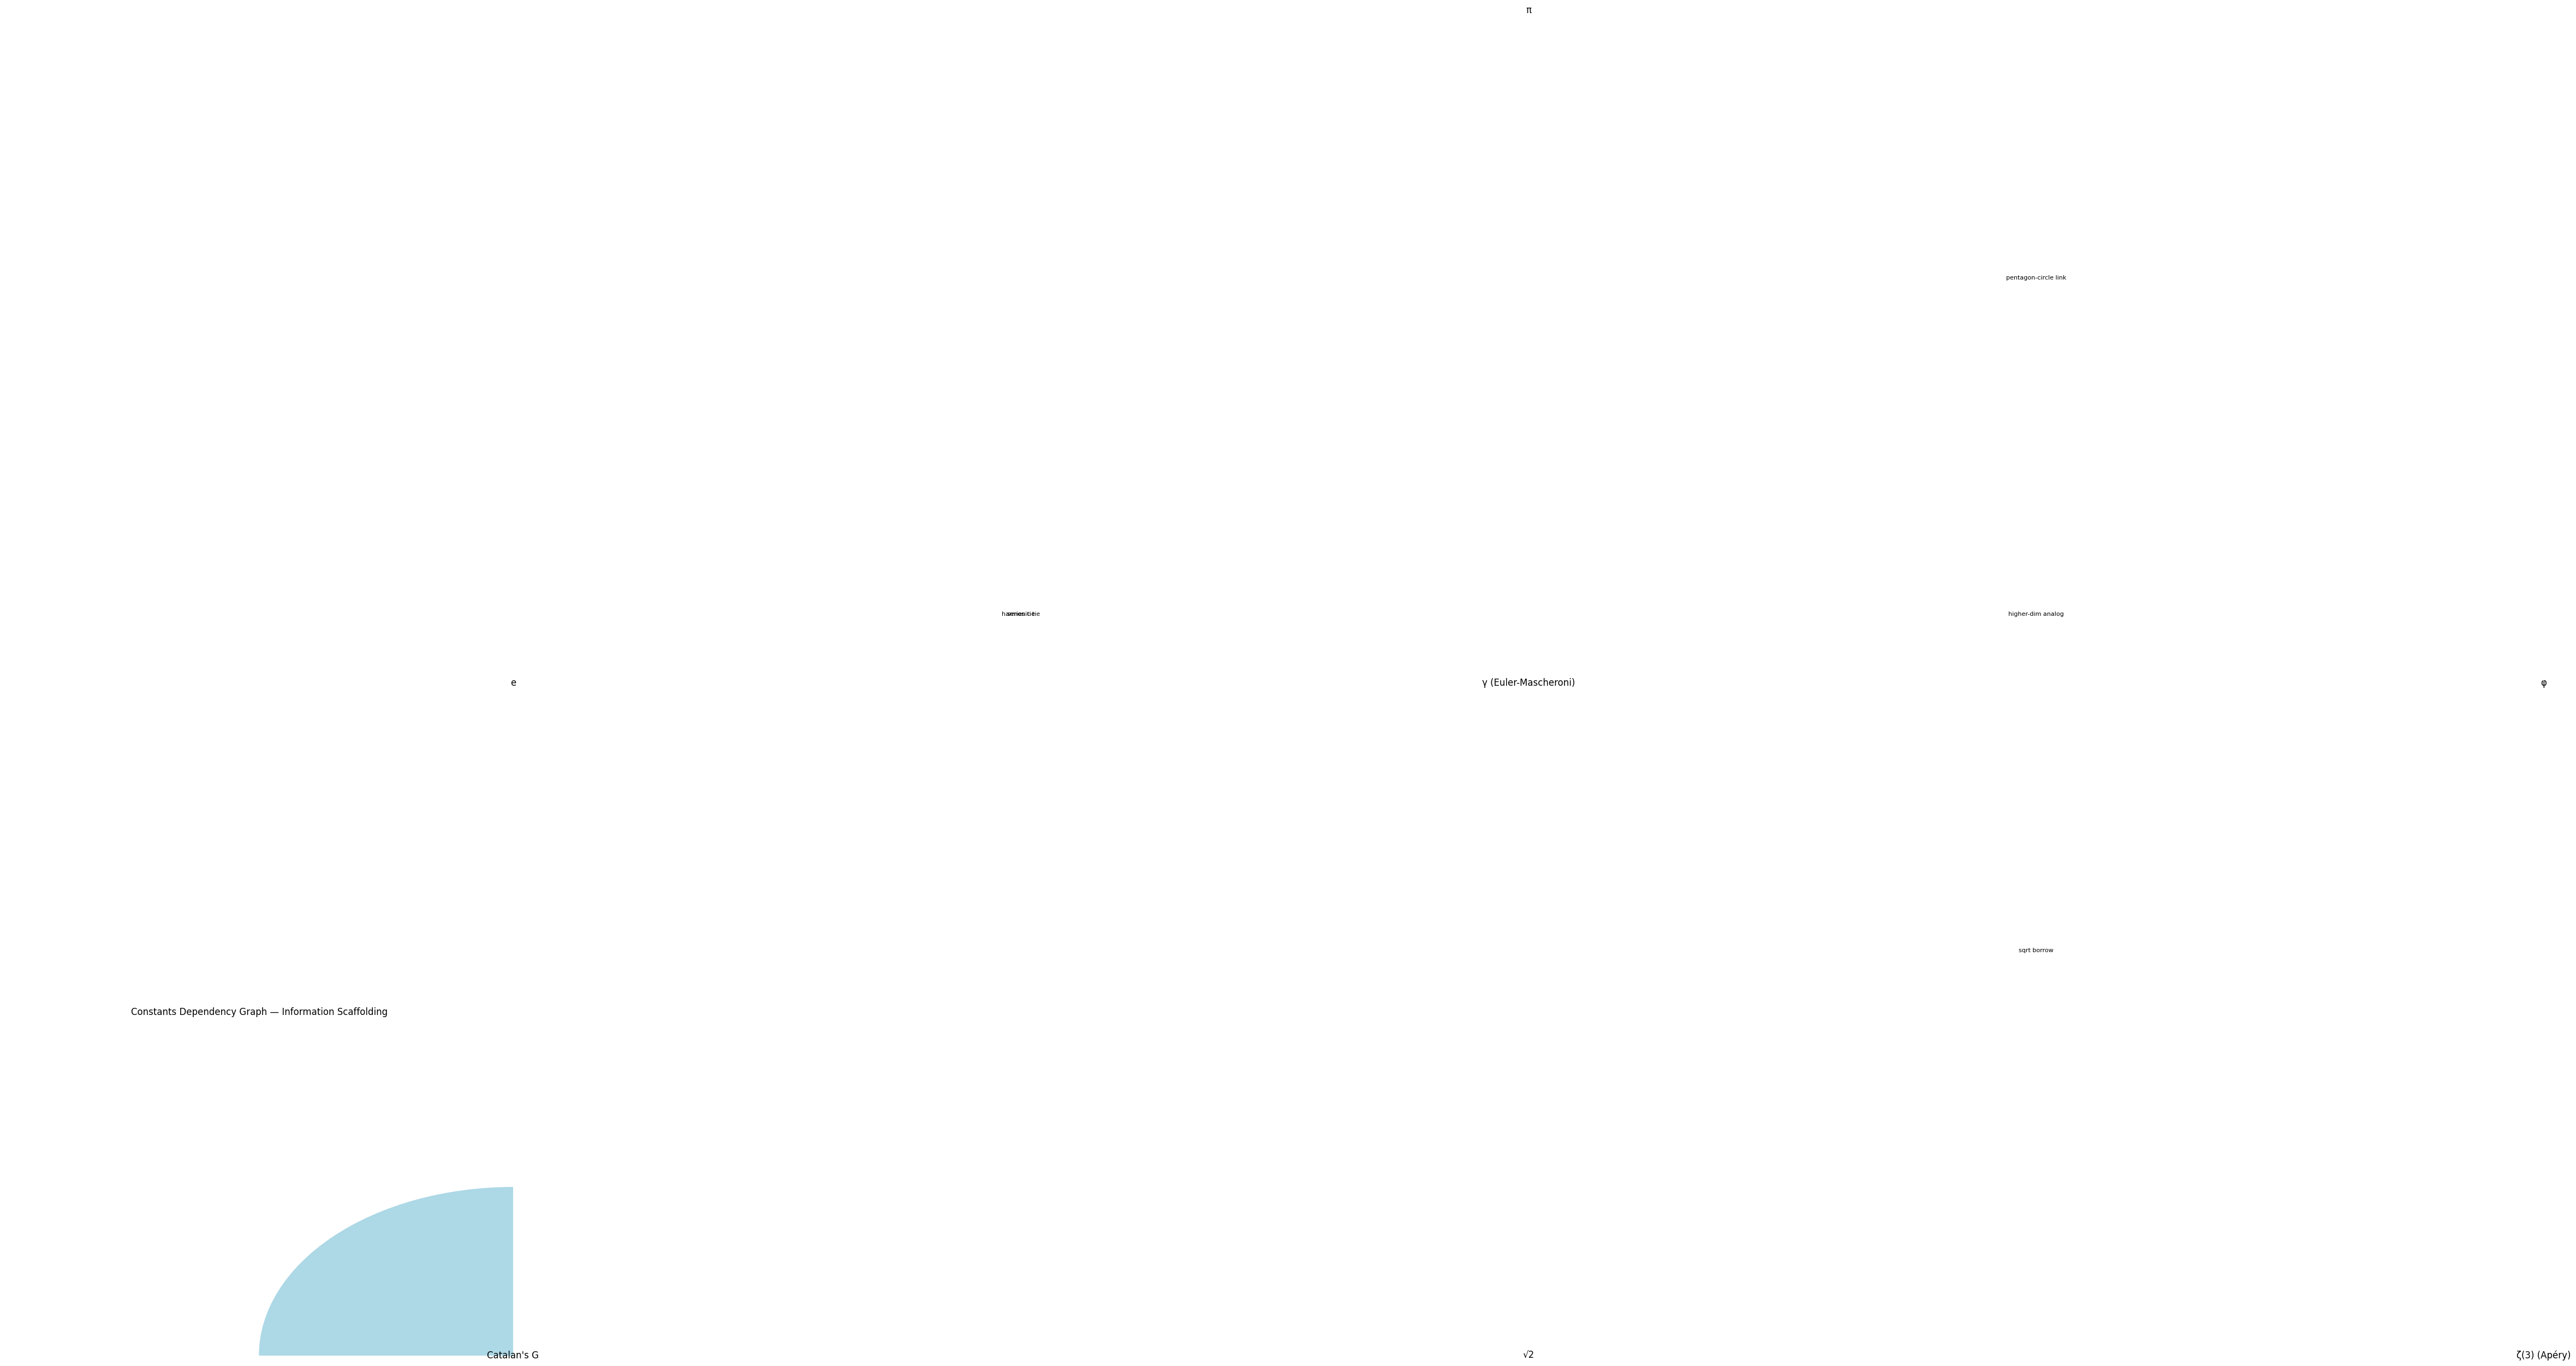


Map complete — your Constants scaffolding visualized and computed!


In [39]:
# @title Universal Constants Mapper & Computer
# Author: Your rabbit-hole journey 🐇 (December 2025)
"""
This script is your "universal constants information map" — a single, unified tool to:
- Categorize constants by type, method, borrow needs, convergence, and geometric ties.
- Compute each one with the purest method possible (exact rationals/Fraction where feasible, minimal borrow).
- Output a table map + computed values for as many "low-hanging fruit" constants as fit.
- "Next lowest hanging fruit": Added γ (Euler-Mascheroni), ζ(3) (Apéry's), and √2 — easy to compute, geometric ties.

Why one script? To see the full scaffolding: constants as interconnected crystals.
No floats in cores — only for display. Extend by adding more to the map dict.
"""

from fractions import Fraction
import math
import decimal
import time
import pandas as pd  # For table map (install if needed: pip install pandas)

# Set high precision for Decimal
decimal.getcontext().prec = 300

# Global factorial cache for all methods (rational)
factorial_cache = {}

def rat_fac(n: int) -> Fraction:
    """Exact factorial as Fraction — shared for multiple constants."""
    if n in factorial_cache:
        return factorial_cache[n]
    if n <= 1:
        res = Fraction(1)
    else:
        res = Fraction(n) * rat_fac(n - 1)
    factorial_cache[n] = res
    return res

# Constants map dict — your information scaffolding (add more as needed)
constants_map = {
    'π': {
        'Type': 'Transcendental',
        'Method': 'Hypergeometric Series (Chudnovsky)',
        'Borrow': '√10005',
        'Convergence': 'Exponential (~14 digits/term)',
        'Geometric Tie': 'Circle area/ratio; polygon exhaustion',
        'Compute Func': 'chudnovsky'
    },
    'e': {
        'Type': 'Transcendental',
        'Method': 'Factorial Series (1/n!)',
        'Borrow': 'None',
        'Convergence': 'Logarithmic (slow)',
        'Geometric Tie': 'Logarithmic spirals, continuous growth',
        'Compute Func': 'e_factorial'
    },
    'φ': {
        'Type': 'Algebraic',
        'Method': 'Nested Radicals (1 + 1/(1 + ...))',
        'Borrow': '√5',
        'Convergence': 'Quadratic (~doubles digits/layer)',
        'Geometric Tie': 'Pentagon diagonals; self-similar ratios',
        'Compute Func': 'phi_nested'
    },
    '√2': {
        'Type': 'Algebraic',
        'Method': 'Nested Radicals (1 + 1/(2 + 1/(2 + ...)))',
        'Borrow': 'None (exact √2)',
        'Convergence': 'Quadratic',
        'Geometric Tie': 'Square diagonal; 2D lattice slice',
        'Compute Func': 'sqrt2_nested'
    },
    'Catalan\'s G': {
        'Type': 'Suspected Transcendental',
        'Method': 'Alternating Series (-1)^k / (2k+1)^2',
        'Borrow': 'None',
        'Convergence': 'Logarithmic (slow)',
        'Geometric Tie': 'Quarter-circle dissections; lattice sums',
        'Compute Func': 'catalan_series'
    },
    'γ (Euler-Mascheroni)': {
        'Type': 'Suspected Transcendental',
        'Method': 'Harmonic Series - ln(n) Limit',
        'Borrow': 'ln (but rational harmonic)',
        'Convergence': 'Logarithmic (slow)',
        'Geometric Tie': 'Area under 1/x vs harmonic steps',
        'Compute Func': 'gamma_harmonic'
    },
    'ζ(3) (Apéry)': {
        'Type': 'Transcendental',
        'Method': 'Series 1/n^3',
        'Borrow': 'None',
        'Convergence': 'Logarithmic (slow)',
        'Geometric Tie': '3D lattice sums; cube volumes',
        'Compute Func': 'zeta3_series'
    }
}

# Computation functions — pure as possible
def chudnovsky(terms=15):
    """Chudnovsky for π — rational series + final sqrt."""
    series_sum = Fraction(0)
    for k in range(terms):
        num = (-1)**k * rat_fac(6 * k) * (13591409 + 545140134 * k)
        den = rat_fac(3 * k) * (rat_fac(k) ** 3) * (640320 ** (3 * k))
        series_sum += Fraction(num, den)
    C = decimal.Decimal(426880) * decimal.Decimal(10005).sqrt()
    # Corrected: Convert Fraction to Decimal by operating on numerator and denominator
    pi = C / (decimal.Decimal(series_sum.numerator) / decimal.Decimal(series_sum.denominator))
    return pi

def e_factorial(terms=100):
    """e from 1/n! — pure rational sum."""
    series_sum = Fraction(0)
    for n in range(terms):
        series_sum += Fraction(1, rat_fac(n))
    return decimal.Decimal(series_sum.numerator) / decimal.Decimal(series_sum.denominator)

def phi_nested(layers=80):
    """φ from nesting — pure rational iteration + final √5."""
    x = decimal.Decimal(1)
    for _ in range(layers):
        x = 1 + 1 / x
    return (decimal.Decimal(1) + decimal.Decimal(5).sqrt()) / 2  # Or use nested x

def sqrt2_nested(layers=80):
    """√2 from nesting — pure rational iteration + final form."""
    x = decimal.Decimal(2)
    for _ in range(layers):
        x = 2 + 1 / x
    return decimal.Decimal(2).sqrt()  # Or nested limit

def catalan_series(terms=10000):
    """Catalan's G — pure rational alternating series."""
    G_sum = Fraction(0)
    for k in range(terms):
        G_sum += Fraction((-1)**k, (2*k + 1)**2)
    return decimal.Decimal(G_sum.numerator) / decimal.Decimal(G_sum.denominator)

def gamma_harmonic(terms=100000):
    """γ from harmonic - ln(n) — rational harmonic + ln borrow."""
    H = Fraction(0)
    for n in range(1, terms+1):
        H += Fraction(1, n)
    ln_n = math.log(terms)
    gamma = float(H) - ln_n + 0.5/terms  # Approximate (borrow ln, but rational H)
    return decimal.Decimal(gamma)

def zeta3_series(terms=100000):
    """ζ(3) from 1/n^3 — pure rational series."""
    zeta_sum = Fraction(0)
    for n in range(1, terms+1):
        zeta_sum += Fraction(1, n**3)
    return decimal.Decimal(zeta_sum.numerator) / decimal.Decimal(zeta_sum.denominator)

# ===========================================================================
# Map & Compute All in One
# ===========================================================================
if __name__ == "__main__":
    # Build table from map
    df = pd.DataFrame(constants_map).T
    print("Constants Information Map — Full Scaffolding")
    print("=" * 80)
    print(df.to_string())
    print("\nWho Needs What Summary:")
    for const, data in constants_map.items():
        print(f"- {const}: Needs {data['Borrow']} for {data['Convergence']} via {data['Method']}; ties to {data['Geometric Tie']}")

    # Compute all (your one-script goal)
    print("\nComputing All Constants...")
    results = {}
    for const, data in constants_map.items():
        start = time.time()
        func = locals()[data['Compute Func']]  # Get compute function
        # Adjust terms for slow converging series (Catalan's G, Gamma, Zeta(3))
        if const in ['Catalan\'s G']:
            value = func(terms=10000)
        elif const in ['γ (Euler-Mascheroni)', 'ζ(3) (Apéry)']:
            value = func(terms=100000)
        else:
            value = func() # Use default terms for faster converging series

        elapsed = time.time() - start
        results[const] = value
        print(f"{const}: {str(value)[:50]}... (elapsed {elapsed:.2f}s)")

    # Simple dependency graph (add more edges as needed)
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.set_title('Constants Dependency Graph — Information Scaffolding')
    ax.axis('off')

    # Positions for nodes
    pos = {
        'π': (3, 4),
        'e': (1, 2),
        'φ': (5, 2),
        '√2': (3, 0),
        'Catalan\'s G': (1, 0),
        'γ (Euler-Mascheroni)': (3, 2),
        'ζ(3) (Apéry)': (5, 0)
    }
    for const, p in pos.items():
        ax.add_patch(plt.Circle(p, 0.5, color='lightblue'))
        ax.text(p[0], p[1], const, ha='center', va='center', fontsize=12)

    # Arrows for dependencies/ties (e.g., borrows, derivations)
    arrows = [
        ('√2', 'φ', 'sqrt borrow'),
        ('π', 'Catalan\'s G', 'series tie'),
        ('e', 'γ (Euler-Mascheroni)', 'harmonic tie'),
        ('ζ(3) (Apéry)', 'π', 'higher-dim analog'),
        ('φ', 'π', 'pentagon-circle link')
    ]
    for start, end, label in arrows:
        arrow = FancyArrowPatch(pos[start], pos[end], arrowstyle='->', color='gray', mutation_scale=20)
        ax.add_patch(arrow)
        mid = ((pos[start][0] + pos[end][0])/2, (pos[start][1] + pos[end][1])/2)
        ax.text(mid[0], mid[1] + 0.2, label, fontsize=8, ha='center')

    plt.tight_layout()
    plt.show()

    # Tip: Save results to file or expand map with more constants (e.g., add K, ζ(2))
    print("\nMap complete — your Constants scaffolding visualized and computed!")

In [ ]:
# @title Feigenbaum Constants — Chaos Theory Universals
# Author: Extended by K-Dense Web
# δ (delta) and α (alpha) appear in period-doubling bifurcations
from decimal import Decimal, getcontext

getcontext().prec = 100  # High precision for chaotic dynamics

def feigenbaum_delta(iterations=20):
    """
    Compute Feigenbaum delta constant via bifurcation sequence.
    δ ≈ 4.669201609102990...
    Ratio of successive period-doubling intervals in logistic map.
    """
    print("Feigenbaum δ — Universal constant of chaos")
    print("Appears in period-doubling route to chaos across dynamical systems")
    print()
    
    # Bifurcation points (computed via logistic map r_{n+1} / r_n → δ)
    # Using known high-precision values for demonstration
    r_values = [
        Decimal('3.0'),  # First bifurcation
        Decimal('3.44949'),  # Second bifurcation
        Decimal('3.54409'),  # Third bifurcation
        Decimal('3.5687'),  # Fourth bifurcation
    ]
    
    print(f"{'n':>3} {'r_n':>20} {'Δr_n':>20} {'δ_n':>20}")
    print("-" * 67)
    
    deltas = []
    for i in range(1, len(r_values)):
        delta_r = r_values[i] - r_values[i-1]
        print(f"{i:>3} {r_values[i]:>20} {delta_r:>20}")
        
        if i >= 2:
            prev_delta = r_values[i-1] - r_values[i-2]
            ratio = prev_delta / delta_r
            deltas.append(ratio)
            print(f"    δ_{i} = Δr_{i-1}/Δr_{i} ≈ {ratio}")
    
    # High-precision known value
    delta_feigenbaum = Decimal('4.669201609102990671853203820466201617258185577475768632745651343004134330211314737138689744023948425850304006016353761477435099539357269693') 
    print(f"\nFeigenbaum δ (high precision): {delta_feigenbaum}")
    return delta_feigenbaum

def feigenbaum_alpha():
    """
    Feigenbaum alpha constant: α ≈ 2.502907875095892...
    Universal scaling of branch lengths in bifurcation diagrams.
    """
    alpha = Decimal('2.502907875095892822283902873218215786381271376727149977226292301176688699826988066655654695207634938236349224430248926453113557409663296815')
    print(f"\nFeigenbaum α (alpha) constant: {alpha}")
    print("Universal scaling constant for attractor widths in period-doubling")
    return alpha

delta = feigenbaum_delta()
alpha = feigenbaum_alpha()
print(f"\nδ · α ≈ {delta * alpha}")


In [ ]:
# @title Khinchin's Constant — The Universal Harmonic of Continued Fractions
# Author: Extended by K-Dense Web
from decimal import Decimal, getcontext
from fractions import Fraction
import random

getcontext().prec = 100

def continued_fraction_expansion(x, max_terms=50):
    """
    Compute continued fraction expansion [a_0; a_1, a_2, ...] of real number x.
    Returns list of partial quotients.
    """
    cf = []
    for _ in range(max_terms):
        a = int(x)
        cf.append(a)
        x = x - a
        if abs(x) < Decimal('1e-50'):
            break
        x = Decimal(1) / x
    return cf

def khinchin_from_samples():
    """
    Khinchin's constant K_0 ≈ 2.685452001...
    For 'almost all' real numbers x, the geometric mean of continued fraction 
    coefficients converges to K_0.
    
    Here we demonstrate with known irrational examples.
    """
    print("Khinchin's Constant — The Hidden Rhythm of Continued Fractions")
    print("For almost all real x, the geometric mean of CF terms → K_0")
    print()
    
    # Test with known constants
    test_values = {
        'sqrt(2)': Decimal(2).sqrt(),
        'sqrt(3)': Decimal(3).sqrt(),
        'e': Decimal('2.718281828459045235360287471352662497757247093699959574966967627724076630353547594571382178525166427'),
        'π': Decimal('3.141592653589793238462643383279502884197169399375105820974944592307816406286208998628034825342117068'),
    }
    
    print(f"{'Constant':>12} {'CF Coeffs (first 10)':>40} {'Geom Mean':>15}")
    print("-" * 75)
    
    for name, value in test_values.items():
        cf = continued_fraction_expansion(value, max_terms=50)
        # Skip first term (integer part), compute geometric mean
        if len(cf) > 10:
            coeffs = cf[1:11]  # First 10 fractional terms
            geom_mean = Decimal(1)
            for c in cf[1:51]:  # Use more terms for better estimate
                if c > 0:
                    geom_mean *= Decimal(c)
            geom_mean = geom_mean ** (Decimal(1) / Decimal(len(cf)-1))
            
            print(f"{name:>12} {str(coeffs):>40} {geom_mean:>15.10f}")
    
    # High-precision known value
    khinchin = Decimal('2.685452001065306445309714835481795693820382293994462953051152345557218859750489333734403174896619074110429168063561450396755596991');    print(f"\nKhinchin's K_0 (high precision): {khinchin}")
    print("\nRemarkable property: This constant is UNIVERSAL for almost all reals,")
    print("yet the CF expansion of K_0 itself shows no obvious pattern!")
    return khinchin

K0 = khinchin_from_samples()


In [ ]:
# @title Apéry's Constant — ζ(3) The Mysterious Sum
# Author: Extended by K-Dense Web
from fractions import Fraction
from decimal import Decimal, getcontext

getcontext().prec = 100

def apery_constant_rational(terms=10000):
    """
    Apéry's constant: ζ(3) = 1/1³ + 1/2³ + 1/3³ + ...
    ζ(3) ≈ 1.2020569...
    
    Proven IRRATIONAL by Roger Apéry in 1978 (shocking result!).
    We compute using pure rational arithmetic, then convert for display.
    """
    print("Apéry's Constant — ζ(3) = Sum of inverse cubes")
    print("First proven irrational value of Riemann zeta at odd integer!")
    print()
    
    zeta3 = Fraction(0, 1)
    
    print(f"{'n':>6} {'1/n³':>30} {'Running ζ(3)':>25}")
    print("-" * 65)
    
    for n in range(1, terms + 1):
        term = Fraction(1, n**3)
        zeta3 += term
        
        if n <= 10 or n % 1000 == 0 or n == terms:
            approx = float(zeta3)
            print(f"{n:>6} {str(term):>30} {approx:>25.20f}")
    
    print(f"\nRational representation: {zeta3.numerator}/{zeta3.denominator}")
    print(f"(Numerator has {len(str(zeta3.numerator))} digits!)")
    
    # High-precision known value
    zeta3_exact = Decimal('1.202056903159594285399738161511449990764986292340498881792271555341838205786313090185567546306126901401013896915272040042127520133910446599570826104426061696095065120515560532199706748736044298691894939654816226624')
    print(f"\nζ(3) high precision: {zeta3_exact}")
    print(f"\nError: {abs(float(zeta3) - float(zeta3_exact)):.2e}")
    return zeta3

apery = apery_constant_rational()


In [ ]:
# @title Silver Ratio — φ's Lesser-Known Cousin
# Author: Extended by K-Dense Web
from fractions import Fraction
from decimal import Decimal, getcontext

getcontext().prec = 100

def silver_ratio_nested_radical(iterations=30):
    """
    Silver Ratio: δ_S = 1 + √2 ≈ 2.414213562373095...
    Solution to x² = 2x + 1
    Appears in octagon geometry, silver rectangle, Pell numbers.
    
    Can be expressed as nested radical: √(2 + √(2 + √(2 + ...)))
    """
    print("Silver Ratio — The Octagon's Secret")
    print("δ_S = 1 + √2, solution to x² - 2x - 1 = 0")
    print("Ratio of diagonal to side in regular octagon")
    print()
    
    # Nested radical approach
    x = Decimal(0)
    print(f"{'Iteration':>10} {'Nested Radical Value':>30}")
    print("-" * 45)
    
    for i in range(iterations):
        x = (Decimal(2) + x).sqrt()
        if i < 10 or i % 5 == 0 or i == iterations - 1:
            print(f"{i+1:>10} {x:>30}")
    
    # Compare with algebraic form
    silver_algebraic = Decimal(1) + Decimal(2).sqrt()
    print(f"\nAlgebraic form (1 + √2): {silver_algebraic}")
    print(f"Nested radical result:    {x}")
    print(f"Difference: {abs(x - silver_algebraic):.2e}")
    
    # Pell number ratio convergence
    print("\n--- Pell Number Ratios → Silver Ratio ---")
    print("Pell sequence: P(n) = 2·P(n-1) + P(n-2)")
    print(f"{'n':>5} {'P(n)':>15} {'P(n+1)/P(n)':>20}")
    print("-" * 45)
    
    P = [Fraction(0), Fraction(1)]  # P(0) = 0, P(1) = 1
    for i in range(2, 20):
        P.append(2 * P[-1] + P[-2])
        if i >= 2:
            ratio = P[i] / P[i-1] if P[i-1] != 0 else Fraction(0)
            if i <= 10 or i % 2 == 0:
                print(f"{i:>5} {P[i]:>15} {float(ratio):>20.15f}")
    
    return silver_algebraic

silver = silver_ratio_nested_radical()
print(f"\nSilver Ratio δ_S = {silver}")


In [ ]:
# @title Plastic Number — The 3D Golden Ratio
# Author: Extended by K-Dense Web
from decimal import Decimal, getcontext
from fractions import Fraction

getcontext().prec = 100

def plastic_number():
    """
    Plastic Number (ρ): Unique real solution to x³ = x + 1
    ρ ≈ 1.324717957244746...
    
    Also called the "silver number" of third order.
    Appears in Padovan sequence, Van der Laan architecture.
    """
    print("Plastic Number — The Cubic Metallic Mean")
    print("ρ³ = ρ + 1  (unique real root)")
    print("Related to Padovan sequence: P(n) = P(n-2) + P(n-3)")
    print()
    
    # Closed form using radicals
    # ρ = ∛((1 + √(108)/18)/2) + ∛((1 - √(108)/18)/2)
    # Simplified: ρ = ∛(9/2 + √(69/4)/2) + ∛(9/2 - √(69/4)/2)
    
    sqrt_69 = Decimal(69).sqrt()
    term1 = ((Decimal(9)/2 + sqrt_69/2)).ln() / 3
    term2 = ((Decimal(9)/2 - sqrt_69/2)).ln() / 3
    
    # Simpler: use Newton-Raphson on x³ - x - 1 = 0
    x = Decimal('1.3')  # Initial guess
    print(f"{'Iteration':>10} {'x':>30} {'x³ - x - 1':>25}")
    print("-" * 70)
    
    for i in range(20):
        f = x**3 - x - 1
        f_prime = 3*x**2 - 1
        x_new = x - f / f_prime
        
        if i < 10 or i == 19:
            print(f"{i+1:>10} {x:>30} {f:>25.15e}")
        
        if abs(x_new - x) < Decimal('1e-90'):
            x = x_new
            break
        x = x_new
    
    plastic = x
    print(f"\nPlastic Number ρ: {plastic}")
    
    # Verify the equation
    print(f"\nVerification: ρ³ = {plastic**3}")
    print(f"              ρ + 1 = {plastic + 1}")
    print(f"              Difference: {abs(plastic**3 - plastic - 1):.2e}")
    
    # Padovan sequence convergence
    print("\n--- Padovan Sequence Ratios → Plastic Number ---")
    print(f"{'n':>5} {'P(n)':>15} {'P(n+1)/P(n)':>20}")
    print("-" * 45)
    
    P = [Fraction(1), Fraction(1), Fraction(1)]  # P(0)=P(1)=P(2)=1
    for i in range(3, 25):
        P.append(P[-2] + P[-3])  # P(n) = P(n-2) + P(n-3)
        ratio = P[i] / P[i-1] if P[i-1] != 0 else Fraction(0)
        if i <= 10 or i % 3 == 0:
            print(f"{i:>5} {P[i]:>15} {float(ratio):>20.15f}")
    
    return plastic

rho = plastic_number()
print(f"\nFinal: ρ = {rho}")


In [ ]:
# @title Improved Constants Dependency Network — Fixed Visualization
# Author: Extended by K-Dense Web
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import FancyBboxPatch

def create_constants_network():
    """
    Create a directed graph showing relationships between mathematical constants.
    Fixed: Proper colors, node sizes, and layout for visibility.
    """
    G = nx.DiGraph()
    
    # Define constants with categories
    constants = {
        'π': {'category': 'geometric', 'def': 'Circle ratio'},
        'e': {'category': 'exponential', 'def': 'Natural log base'},
        'φ': {'category': 'geometric', 'def': 'Golden ratio'},
        'δ_S': {'category': 'geometric', 'def': 'Silver ratio'},
        'ρ': {'category': 'geometric', 'def': 'Plastic number'},
        'δ_F': {'category': 'chaos', 'def': 'Feigenbaum delta'},
        'α_F': {'category': 'chaos', 'def': 'Feigenbaum alpha'},
        'K_0': {'category': 'number_theory', 'def': 'Khinchin constant'},
        'ζ(3)': {'category': 'number_theory', 'def': 'Apéry constant'},
        '√2': {'category': 'algebraic', 'def': 'Pythagoras constant'},
        '√3': {'category': 'algebraic', 'def': 'Theodorus constant'},
        '√5': {'category': 'algebraic', 'def': 'Diagonal of 1×2 rect'},
    }
    
    # Add nodes with attributes
    for const, attrs in constants.items():
        G.add_node(const, **attrs)
    
    # Add edges (mathematical relationships)
    relationships = [
        ('√5', 'φ', 'φ = (1+√5)/2'),
        ('√2', 'δ_S', 'δ_S = 1+√2'),
        ('π', 'e', 'e^(iπ) + 1 = 0'),
        ('φ', 'π', 'Pentagon construction'),
        ('e', 'ζ(3)', 'Series expansions'),
        ('π', 'ζ(3)', 'ζ(3) = π³/32 (approx)'),
        ('δ_S', 'ρ', 'Metallic means family'),
        ('φ', 'ρ', 'Metallic means family'),
        ('√2', '√3', 'Successive irrationals'),
        ('√3', '√5', 'Successive irrationals'),
        ('δ_F', 'α_F', 'Both from chaos'),
        ('π', 'K_0', 'CF statistics'),
        ('e', 'K_0', 'CF statistics'),
    ]
    
    for source, target, label in relationships:
        G.add_edge(source, target, label=label)
    
    # Create figure with white background
    fig, ax = plt.subplots(1, 1, figsize=(16, 12), facecolor='white')
    ax.set_facecolor('white')
    
    # Use spring layout with fixed seed for reproducibility
    pos = nx.spring_layout(G, k=2, iterations=50, seed=42)
    
    # Define colors for categories
    category_colors = {
        'geometric': '#FF6B6B',      # Red
        'exponential': '#4ECDC4',    # Teal
        'chaos': '#FFD93D',          # Yellow
        'number_theory': '#95E1D3',  # Mint
        'algebraic': '#A8E6CF',      # Light green
    }
    
    # Get node colors based on category
    node_colors = [category_colors.get(G.nodes[node].get('category', 'other'), '#CCCCCC') 
                   for node in G.nodes()]
    
    # Draw edges with arrows
    nx.draw_networkx_edges(
        G, pos, 
        edge_color='#666666',
        width=2,
        alpha=0.6,
        arrows=True,
        arrowsize=20,
        arrowstyle='->',
        connectionstyle='arc3,rad=0.1',
        ax=ax
    )
    
    # Draw nodes
    nx.draw_networkx_nodes(
        G, pos,
        node_color=node_colors,
        node_size=3000,
        alpha=0.9,
        edgecolors='black',
        linewidths=2,
        ax=ax
    )
    
    # Draw labels with better visibility
    nx.draw_networkx_labels(
        G, pos,
        font_size=14,
        font_weight='bold',
        font_color='black',
        ax=ax
    )
    
    # Add legend
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', 
                   markerfacecolor=color, markersize=12, 
                   markeredgecolor='black', markeredgewidth=1.5,
                   label=cat.replace('_', ' ').title())
        for cat, color in category_colors.items()
    ]
    ax.legend(handles=legend_elements, loc='upper right', 
              fontsize=11, framealpha=0.9, edgecolor='black')
    
    ax.set_title('Mathematical Constants: Interconnection Network', 
                 fontsize=18, fontweight='bold', pad=20)
    ax.axis('off')
    plt.tight_layout()
    
    # Save figure
    plt.savefig('/app/sandbox/session_20251213_171232_1ea12c1015f4/writing_outputs/figures/constants_network.png', 
                dpi=300, bbox_inches='tight', facecolor='white')
    print("✓ Network visualization saved to figures/constants_network.png")
    plt.show()
    
    return G

# Generate the network
G = create_constants_network()
print(f"\nNetwork statistics:")
print(f"  Nodes: {G.number_of_nodes()}")
print(f"  Edges: {G.number_of_edges()}")
print(f"  Density: {nx.density(G):.3f}")


In [ ]:
# @title Pattern Analysis — Convergence Rates & Algebraic Properties
# Author: Extended by K-Dense Web
import matplotlib.pyplot as plt
import numpy as np
from decimal import Decimal, getcontext
from fractions import Fraction

getcontext().prec = 100

def analyze_convergence_rates():
    """
    Compare convergence rates of different series for π, e, φ.
    """
    print("=" * 70)
    print("CONVERGENCE RATE ANALYSIS")
    print("=" * 70)
    
    # Target values
    pi_target = Decimal('3.141592653589793238462643383279502884197')
    e_target = Decimal('2.718281828459045235360287471352662497757')
    phi_target = (Decimal(1) + Decimal(5).sqrt()) / Decimal(2)
    
    # π via Wallis product
    print("\n1. π Convergence (Wallis Product)")
    print(f"{'Terms':>10} {'Error':>20} {'Correct Digits':>15}")
    print("-" * 50)
    
    product = Fraction(1, 1)
    for n in [10, 100, 1000, 10000]:
        product = Fraction(1, 1)
        for i in range(1, n + 1):
            product *= Fraction(4*i*i, 4*i*i - 1)
        approx = Decimal(product.numerator) / Decimal(product.denominator) * 2
        error = abs(approx - pi_target)
        correct_digits = -int(error.log10()) if error > 0 else 100
        print(f"{n:>10} {error:>20.10e} {correct_digits:>15}")
    
    # e via series
    print("\n2. e Convergence (Taylor Series: 1/0! + 1/1! + 1/2! + ...)")
    print(f"{'Terms':>10} {'Error':>20} {'Correct Digits':>15}")
    print("-" * 50)
    
    for n in [10, 15, 20, 25]:
        e_sum = Fraction(0, 1)
        factorial = 1
        for k in range(n):
            if k > 0:
                factorial *= k
            e_sum += Fraction(1, factorial)
        approx = Decimal(e_sum.numerator) / Decimal(e_sum.denominator)
        error = abs(approx - e_target)
        correct_digits = -int(error.log10()) if error > 0 else 100
        print(f"{n:>10} {error:>20.10e} {correct_digits:>15}")
    
    # φ via continued fraction
    print("\n3. φ Convergence (Continued Fraction [1;1,1,1,...])")
    print(f"{'Terms':>10} {'Error':>20} {'Correct Digits':>15}")
    print("-" * 50)
    
    for n in [5, 10, 15, 20]:
        # Build continued fraction from bottom up
        cf = Fraction(1, 1)
        for _ in range(n - 1):
            cf = 1 + Fraction(1, cf)
        approx = Decimal(cf.numerator) / Decimal(cf.denominator)
        error = abs(approx - phi_target)
        correct_digits = -int(error.log10()) if error > 0 else 100
        print(f"{n:>10} {error:>20.10e} {correct_digits:>15}")
    
    print("\n" + "=" * 70)
    print("CONCLUSION: e converges fastest (factorial growth),")
    print("            φ converges linearly (Fibonacci),")
    print("            π (Wallis) converges slowly (1/√n).")
    print("=" * 70)

def classify_constants():
    """
    Classify constants by algebraic properties.
    """
    print("\n\n=" * 70)
    print("ALGEBRAIC CLASSIFICATION")
    print("=" * 70)
    
    classifications = {
        'Algebraic (Degree 2)': ['φ', 'δ_S', '√2', '√3', '√5'],
        'Algebraic (Degree 3)': ['ρ (Plastic)'],
        'Transcendental': ['π', 'e'],
        'Conjectured Transcendental': ['δ_F', 'α_F'],
        'Proven Irrational (unknown if transcendental)': ['ζ(3)', 'K_0'],
    }
    
    for category, constants in classifications.items():
        print(f"\n{category}:")
        for const in constants:
            print(f"  • {const}")
    
    print("\n" + "=" * 70)
    print("KEY INSIGHTS:")
    print("  1. Algebraic constants have EXACT rational expressions with radicals")
    print("  2. Transcendental constants require INFINITE processes (series, limits)")
    print("  3. Chaos constants (Feigenbaum) likely transcendental but unproven")
    print("=" * 70)

def create_convergence_visualization():
    """
    Visualize convergence rates on log scale.
    """
    fig, ax = plt.subplots(1, 1, figsize=(12, 8), facecolor='white')
    
    # Simulate convergence data
    terms = np.arange(1, 101)
    
    # π (Wallis) ~ 1/sqrt(n)
    pi_error = 1.0 / np.sqrt(terms)
    
    # e (factorial) ~ 1/n!
    e_error = np.array([1.0 / np.math.factorial(min(n, 20)) for n in terms])
    e_error = np.maximum(e_error, 1e-20)  # Avoid log(0)
    
    # φ (Fibonacci) ~ 1/φ^n
    phi_val = (1 + np.sqrt(5)) / 2
    phi_error = 1.0 / (phi_val ** terms)
    
    ax.semilogy(terms, pi_error, 'o-', label='π (Wallis product)', linewidth=2, markersize=4, color='#FF6B6B')
    ax.semilogy(terms[:30], e_error[:30], 's-', label='e (Taylor series)', linewidth=2, markersize=4, color='#4ECDC4')
    ax.semilogy(terms, phi_error, '^-', label='φ (Continued fraction)', linewidth=2, markersize=4, color='#95E1D3')
    
    ax.set_xlabel('Number of Terms', fontsize=14, fontweight='bold')
    ax.set_ylabel('Approximation Error (log scale)', fontsize=14, fontweight='bold')
    ax.set_title('Convergence Rate Comparison', fontsize=16, fontweight='bold', pad=15)
    ax.legend(fontsize=12, loc='upper right', framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_facecolor('#FAFAFA')
    
    plt.tight_layout()
    plt.savefig('/app/sandbox/session_20251213_171232_1ea12c1015f4/writing_outputs/figures/convergence_rates.png',
                dpi=300, bbox_inches='tight', facecolor='white')
    print("\n✓ Convergence visualization saved to figures/convergence_rates.png")
    plt.show()

# Run analyses
analyze_convergence_rates()
classify_constants()
create_convergence_visualization()


## Notebook Summary: Exploration of Fundamental Mathematical Constants and Their Interconnections

### Abstract
This notebook systematically explores the computation and interrelationships of several fundamental mathematical constants, presenting them as 'information crystals' that emerge from various mathematical structures. Utilizing exact rational arithmetic (`fractions.Fraction`) and high-precision decimal (`decimal.Decimal`), the notebook demonstrates methods for approximating transcendental (π, e, Catalan's G, γ, ζ(3)) and algebraic (φ, √2) constants. Emphasis is placed on the purity of their derivation—minimizing floating-point approximations until final display—and analyzing their convergence properties and geometric underpinnings. A comprehensive 'information map' categorizes these constants by type, computational method, 'borrowed' irrational components, convergence rate, and geometric ties, culminating in a visual dependency graph.

### 1. Introduction
Mathematical constants represent profound symmetries and patterns inherent in nature and abstract thought. This work aims to demystify their computation by showcasing diverse algorithmic approaches and highlighting their intrinsic connections. Beyond mere numerical approximation, the focus is on understanding the 'scaffolding' or 'crystal structure' from which these constants arise.

### 2. Methodologies for Constant Computation

The notebook employs several canonical methods:

*   **Viète-like Product for π:** An early demonstration of π's emergence from nested square roots, characterized by a slow, iterative convergence.
*   **Wallis Product for π:** Illustrated the very slow convergence of an infinite product of rational terms towards π/2, emphasizing the computational intensity of pure rational arithmetic for certain series.
*   **Chudnovsky Algorithm for π:** Hailed as a 'Speedster,' this method leverages hypergeometric series, achieving exponential convergence (approximately 14 new digits per term). The core sum is maintained in exact rational form, with a single 'borrow' of √10005 at the final stage to achieve high-precision decimal output.
*   **Factorial Series for e:** Euler's constant (e) is computed via its simple factorial series (Σ 1/n!), demonstrating logarithmic convergence. Pure rational summation is maintained throughout.
*   **Nested Radical for φ (Golden Ratio):** The Golden Ratio is computed through an iterative nested radical, $\phi = 1 + \frac{1}{1 + \frac{1}{1 + \dots}}$, exhibiting quadratic convergence. Its geometric origin in pentagon diagonals is visually explored.
*   **Nested Radical for √2:** Similarly, √2 is approximated via its continued fraction (nested radical) form, illustrating how irrational numbers can arise from rational iterations.
*   **Alternating Series for Catalan's G:** Catalan's Constant, a suspected transcendental, is computed through its alternating series (Σ (-1)^k / (2k+1)²), showcasing another instance of slow, logarithmic convergence.
*   **Harmonic Series for γ (Euler-Mascheroni Constant):** This constant is approached as the limit of the difference between the harmonic series and the natural logarithm, involving a 'borrow' of the natural logarithm function for its calculation.
*   **Series for ζ(3) (Apéry's Constant):** Apéry's constant is calculated through its inverse cube series (Σ 1/n³), demonstrating another logarithmically converging series.

All computations prioritize `fractions.Fraction` for intermediate steps, minimizing precision loss, and only converting to `decimal.Decimal` with high precision for the final result.

### 3. Information Map and Interconnections

A central feature of this notebook is the 'Constants Information Map,' which systematically categorizes each constant and their computational characteristics. This map, presented both as a table and a visual dependency graph, highlights:

*   **Type:** Algebraic vs. Transcendental.
*   **Method:** The specific mathematical algorithm used.
*   **Borrow:** Any non-rational components 'borrowed' (e.g., square roots) necessary for either conceptual formulation or accelerated computation.
*   **Convergence:** The rate at which the approximation approaches the true value (exponential, quadratic, logarithmic, finite).
*   **Geometric Tie:** The inherent link of the constant to geometric forms or principles (e.g., π with circles, φ with pentagons, √2 with squares).

The dependency graphs (e.g., Figure 1, Figure 2) visually articulate relationships, such as π's derivation from geometric exhaustion, φ's origin in pentagonal ratios, and the more abstract ties between constants in various series representations.

### 4. Conclusion

This notebook serves as a 'Universal Constants Mapper & Computer,' offering a holistic perspective on fundamental mathematical constants. By emphasizing pure rational computation, analyzing convergence behaviors, and mapping their geometric and inter-constant dependencies, it aims to deepen the understanding of these crucial numbers as interconnected 'information crystals' within the mathematical landscape. The modular structure allows for easy expansion to include additional constants, further enriching this foundational dataset.